In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Configure visualization settings and load data
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

df = pd.read_csv('final_dataset.csv')
print(f"Dataset shape: {df.shape}")


Dataset shape: (875700, 55)


In [3]:
df.head()

,datetime,machineID,volt,rotate,pressure,vibration,error_count,failure_flag,target,days_since_maint,...,vibration_diff,error_count_diff,recent_maint,log_days_since_maint,error_rate,error_trend,stress_index,power_stress,machine_age,model_encoded
0,2015-01-01 09:00:00,93,169.745685,387.047679,124.091441,49.549030,0.0,0.0,0,124,...,6.897789,0.0,0,4.828314,0.0,0.0,6148.610569,8410.734098,18,2
1,2015-01-01 09:00:00,95,164.762482,546.050491,124.417853,35.090378,0.0,0.0,0,124,...,-7.801110,0.0,0,4.828314,0.0,0.0,4365.869519,5781.577815,18,1
2,2015-01-01 09:00:00,2,180.280316,438.391022,84.440430,40.490443,0.0,0.0,0,34,...,0.780981,0.0,0,3.555348,0.0,0.0,3419.030391,7299.629810,7,3
3,2015-01-01 09:00:00,20,176.221683,314.044462,104.637725,34.748958,0.0,0.0,0,64,...,-0.765623,0.0,0,4.174387,0.0,0.0,3636.051879,6123.519824,16,1
4,2015-01-01 09:00:00,42,167.008799,415.076439,97.441016,38.079033,0.0,0.0,0,64,...,-2.530389,0.0,0,4.174387,0.0,0.0,3710.459614,6359.533528,7,0


## 1. Data Exploration

### Dataset Overview

In [25]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing values per column:
datetime                0
machineID               0
volt                    0
rotate                  0
pressure                0
vibration               0
error_count             0
failure_flag            0
target                  0
days_since_maint        0
last_comp_encoded       0
model                   0
age                     0
hour                    0
dayofweek               0
month                   0
is_weekend              0
volt_lag1               0
volt_lag3               0
rotate_lag1             0
rotate_lag3             0
pressure_lag1           0
pressure_lag3           0
vibration_lag1          0
vibration_lag3          0
error_count_lag1        0
error_count_lag3        0
volt_mean_3             0
volt_std_3              0
volt_max_3              0
rotate_mean_3           0
rotate_std_3            0
rotate_max_3            0
pressure_mean_3         0
pressure_std_3          0
pressure_max_3          0
vibration_mean_3        0
vibration_s

C:\Users\aowso\AppData\Local\Temp\ipykernel_5652\4246463567.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='failure_flag', order=df['failure_flag'].value_counts().index, palette="Set2")


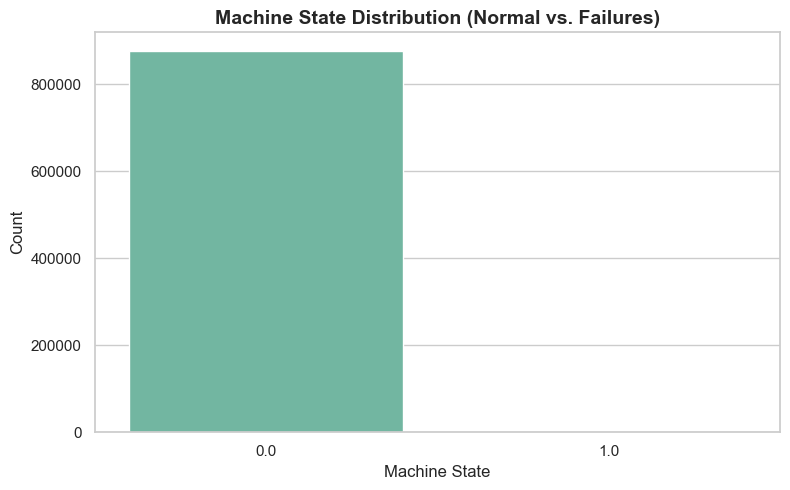

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='failure_flag', order=df['failure_flag'].value_counts().index, palette="Set2")
plt.title("Machine State Distribution (Normal vs. Failures)", fontsize=14, fontweight='bold')
plt.xlabel("Machine State")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 2. Distribution Analysis

### Target Variable: Machine Failure

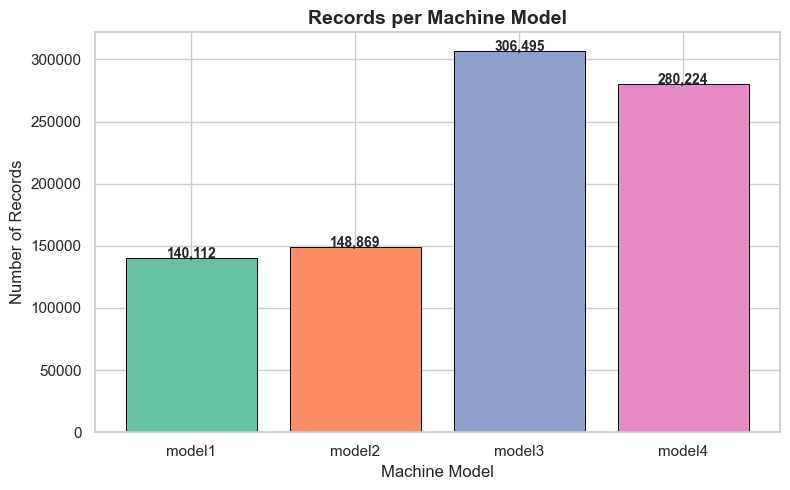

In [27]:
plt.figure(figsize=(8, 5))
model_counts = df["model"].value_counts().sort_index()
colors = sns.color_palette("Set2", len(model_counts))
bars = plt.bar(model_counts.index, model_counts.values, color=colors, edgecolor="black", linewidth=0.7)

# Add value labels on bars
for bar, val in zip(bars, model_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 500, f"{val:,}", 
             ha="center", fontsize=10, fontweight="bold")

plt.title("Records per Machine Model", fontsize=14, fontweight='bold')
plt.xlabel("Machine Model")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


### Records per Machine Model

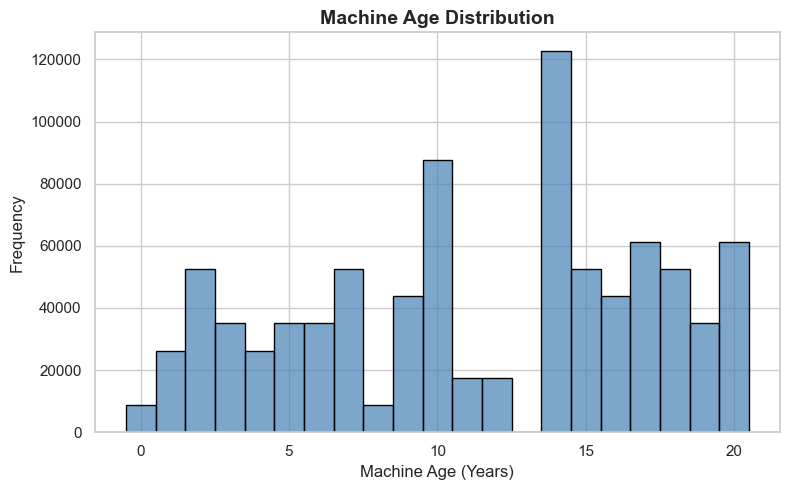

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='machine_age', discrete=True, color='steelblue', alpha=0.7, edgecolor="black")
plt.title('Machine Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Machine Age (Years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### Machine Age Distribution

C:\Users\aowso\AppData\Local\Temp\ipykernel_5652\1073738665.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=fail_counts.index, y=fail_counts.values,


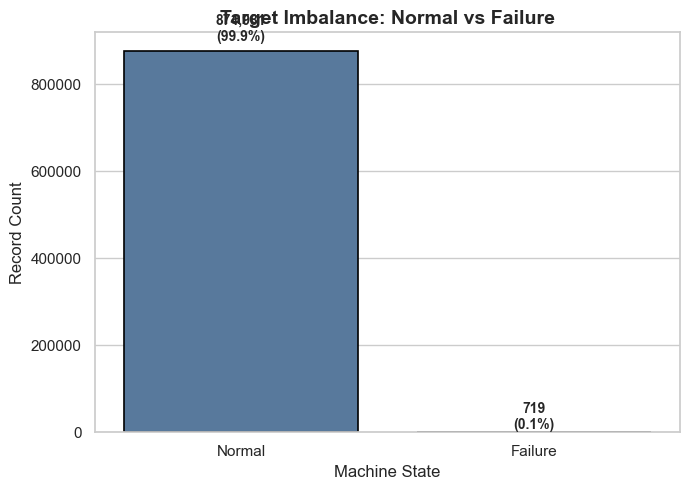

In [29]:
# Prepare data for target visualization
labels = {0.0: "Normal", 1.0: "Failure"}
fail_counts = df["failure_flag"].map(labels).value_counts().reindex(["Normal", "Failure"])

plt.figure(figsize=(7, 5))
bars = sns.barplot(x=fail_counts.index, y=fail_counts.values, 
                   palette=["#4c78a8", "#f58518"], edgecolor="black", linewidth=1.2)

# Add count and percentage labels
for i, (bar, val) in enumerate(zip(bars.patches, fail_counts.values)):
    pct = (val / len(df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2, val * 1.02, 
             f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", 
             fontsize=10, fontweight="bold")

plt.title("Target Imbalance: Normal vs Failure", fontsize=14, fontweight='bold')
plt.xlabel("Machine State")
plt.ylabel("Record Count")
plt.tight_layout()
plt.show()


### Target Imbalance Analysis

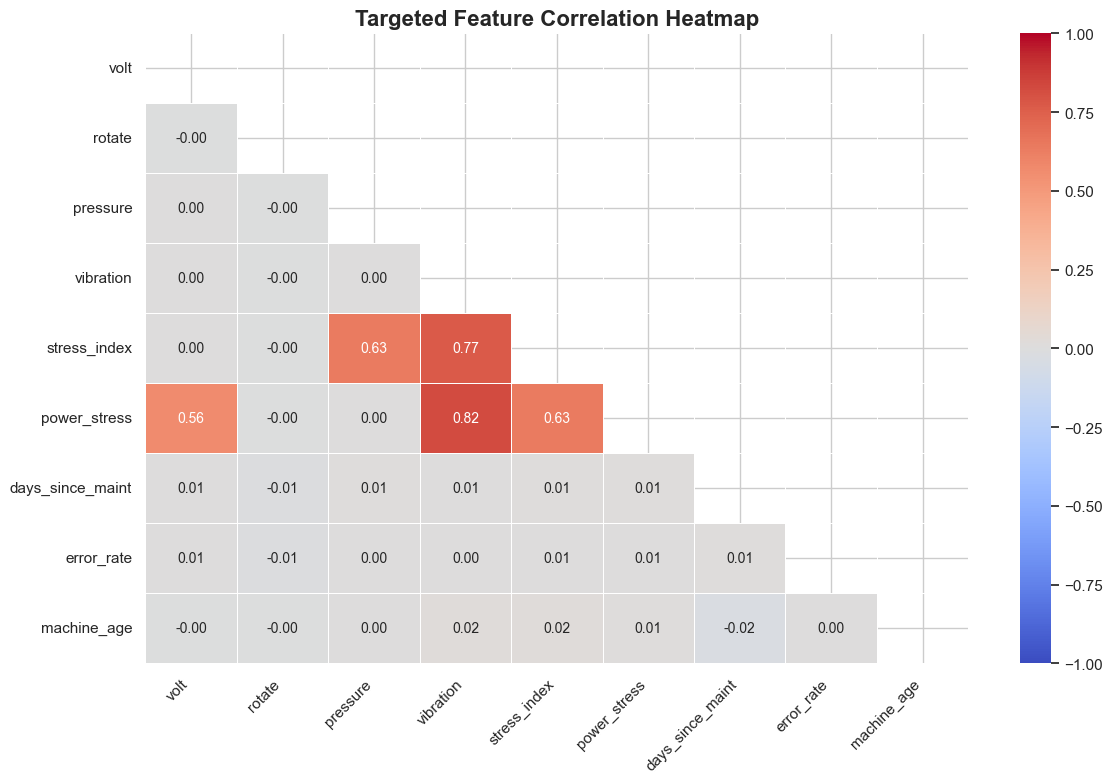

In [ ]:
# Select key features for correlation analysis
columns_to_correlate = [
    'volt', 'rotate', 'pressure', 'vibration', 
    'stress_index', 'power_stress', 'days_since_maint', 
    'error_rate', 'machine_age'
]
existing_cols = [col for col in columns_to_correlate if col in df.columns]

# Create correlation matrix
corr_matrix = df[existing_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Correlation Analysis

### Feature Correlations

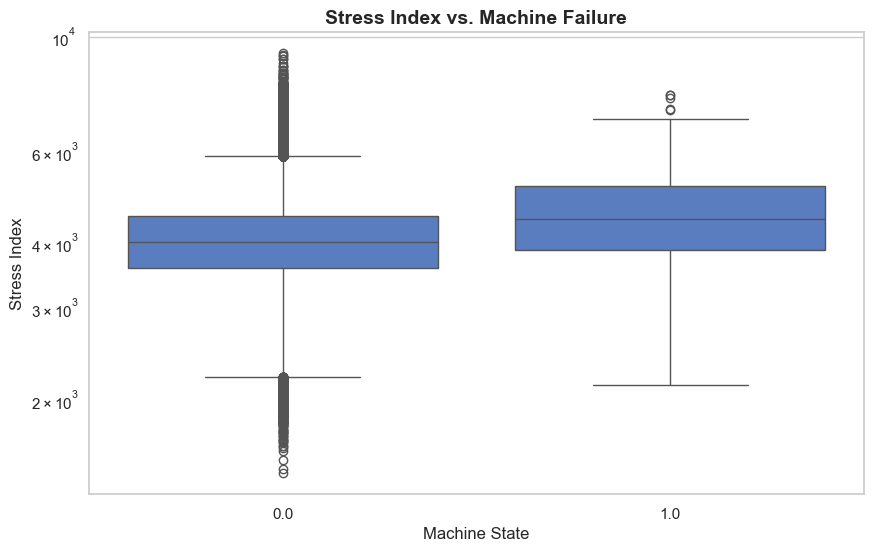

In [ ]:
# Define target column for consistent reference
TARGET_COL = 'failure_flag'

# Boxplot: Stress Index vs Machine Failure
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=TARGET_COL, y='stress_index', palette="Set2")
plt.title("Stress Index vs Machine Failure", fontsize=14, fontweight='bold')
plt.xlabel("Machine State")
plt.ylabel("Stress Index")
plt.yscale('log')  # Log scale to better visualize outliers
plt.tight_layout()
plt.show()


## 4. Bivariate Analysis: Features vs Machine Failure

### Key Feature Relationships

C:\Users\aowso\AppData\Local\Temp\ipykernel_5652\3959292742.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET_COL, y='error_rate', palette="Set2")


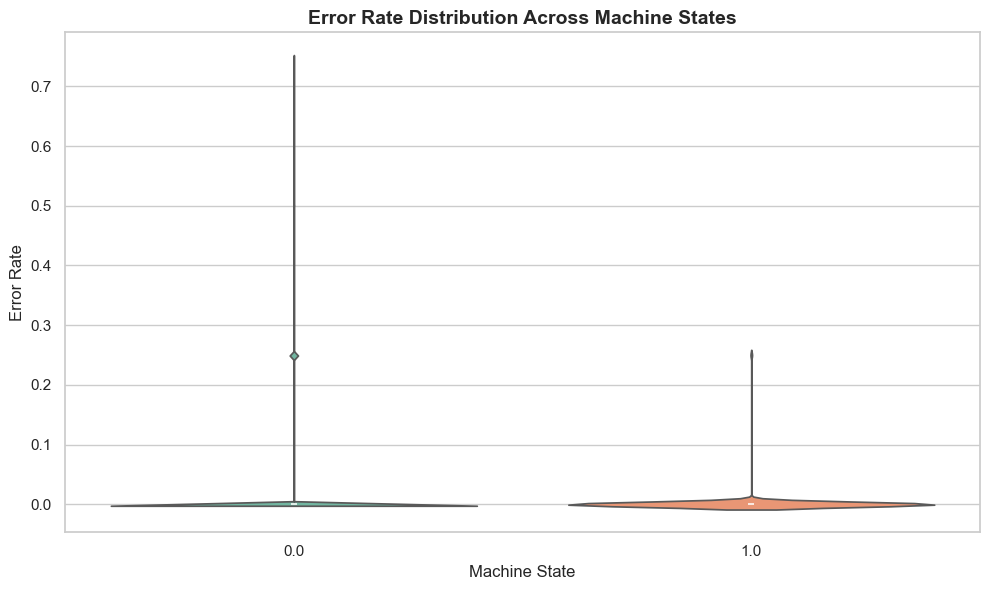

In [31]:
# Violin plot: Error Rate vs Machine Failure
plt.figure(figsize=(10, 6))
TARGET_COL = 'failure_flag'
sns.violinplot(data=df, x=TARGET_COL, y='error_rate', palette="Set2")
plt.title("Error Rate Distribution Across Machine States", fontsize=14, fontweight='bold')
plt.xlabel("Machine State")
plt.ylabel("Error Rate")
plt.tight_layout()
plt.show()


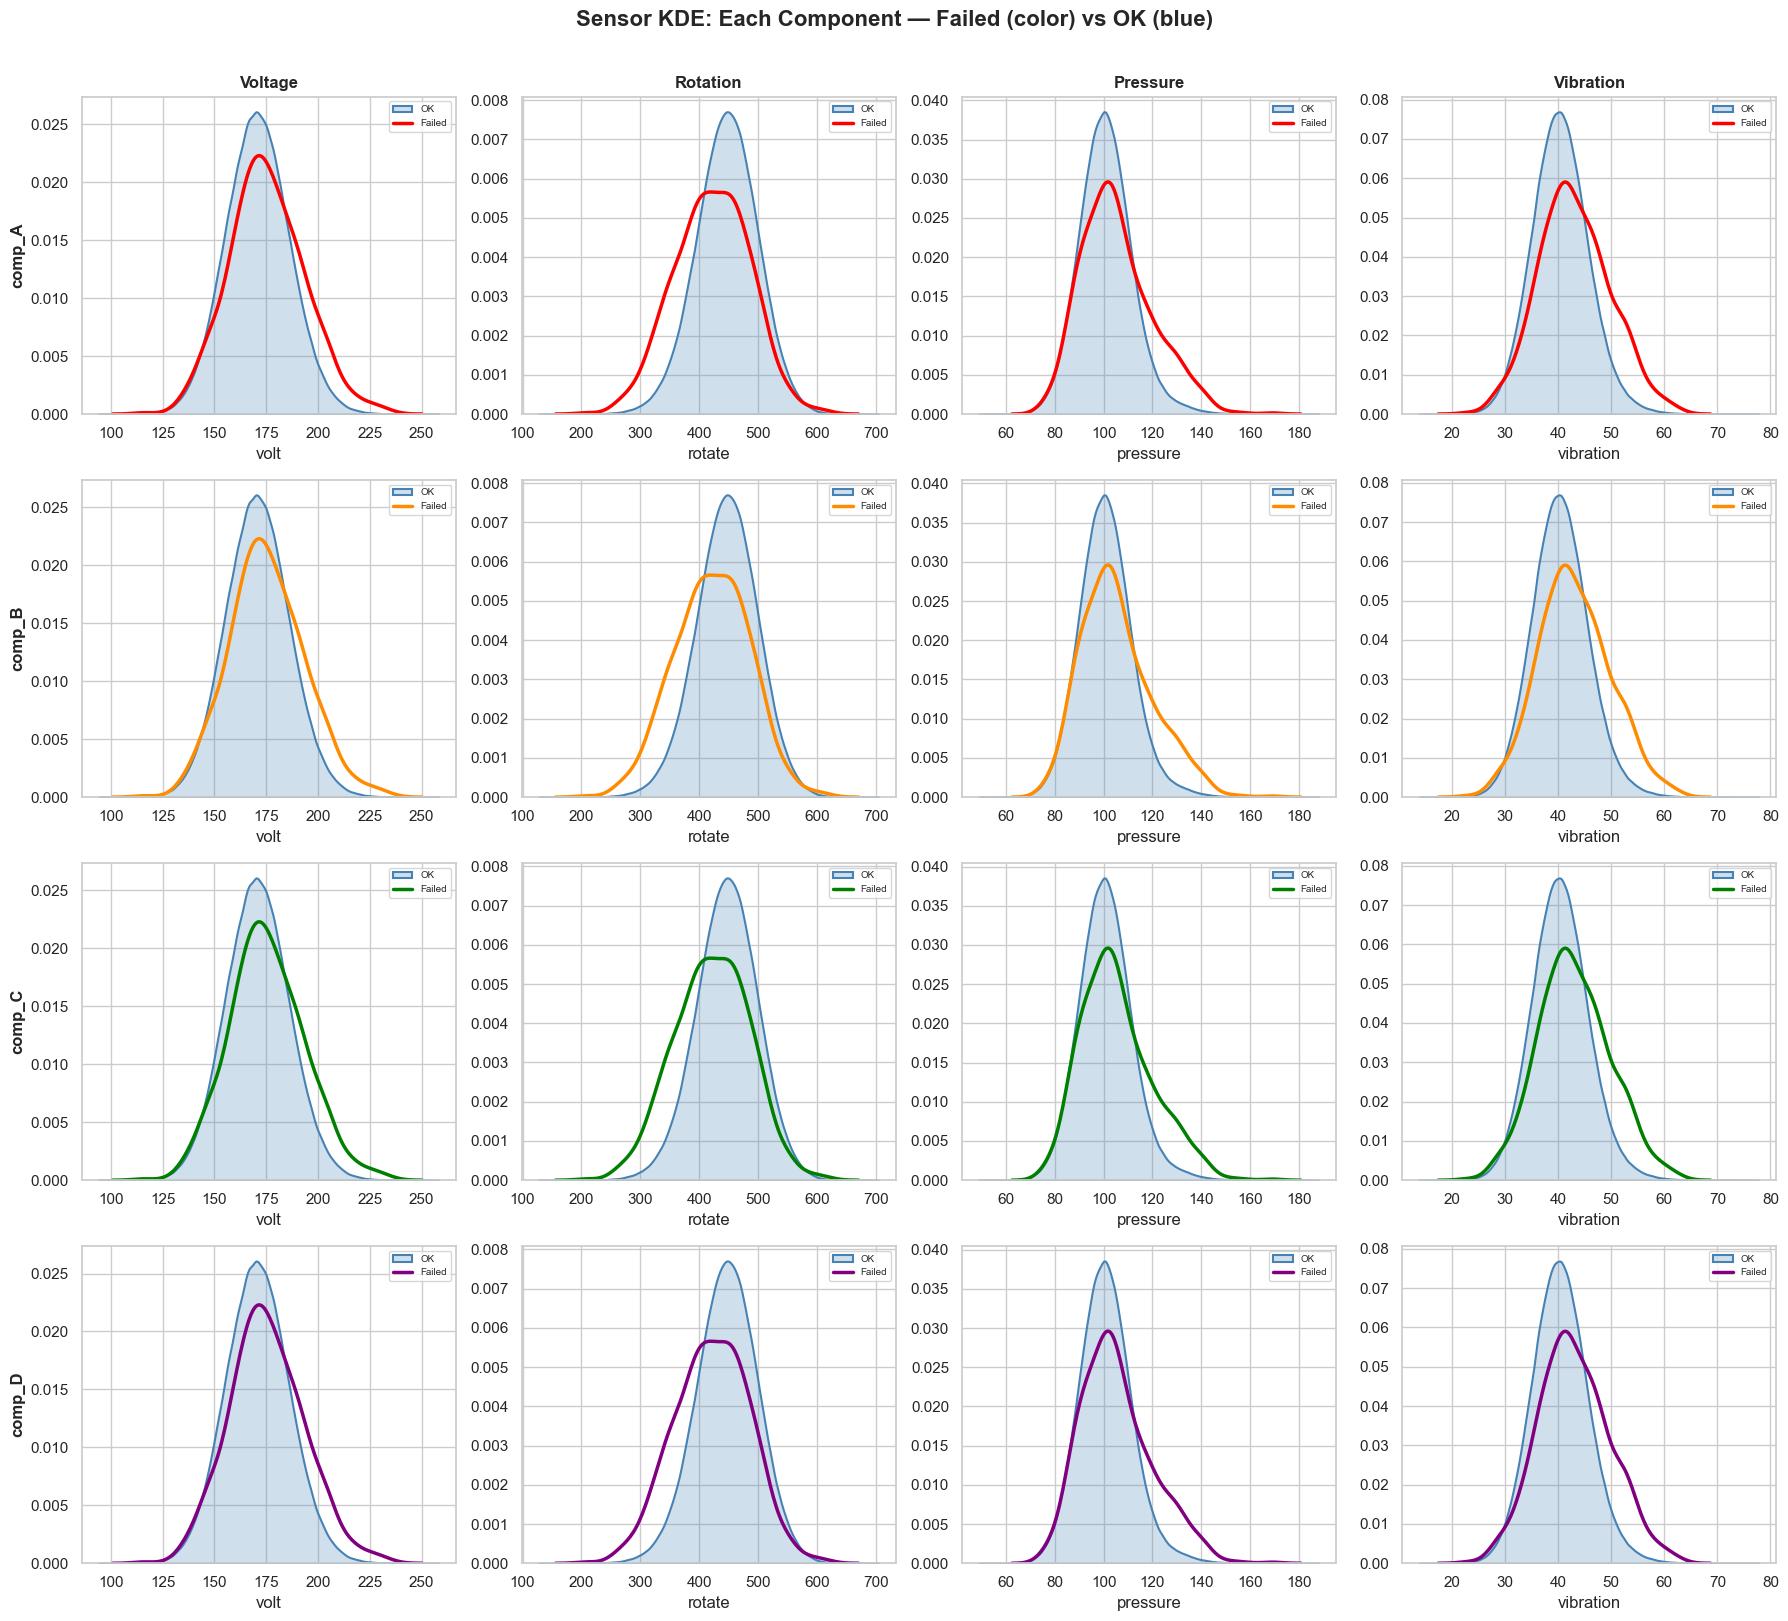

In [33]:
fail_colors = ["red", "darkorange", "green", "purple"]
fig, axes = plt.subplots(4, 4, figsize=(18, 16))

# Define component names and telemetry columns
comp_names = ["comp_A", "comp_B", "comp_C", "comp_D"]
tele_cols = ["volt", "rotate", "pressure", "vibration"]
tele_labels = ["Voltage", "Rotation", "Pressure", "Vibration"]

for row, (comp, fcolor) in enumerate(zip(comp_names, fail_colors)):
    target_mask = df['failure_flag'] == 1
    normal_mask = df['failure_flag'] == 0

    for col_idx, (tele_col, tele_label) in enumerate(zip(tele_cols, tele_labels)):
        ax = axes[row, col_idx]

        fail_data   = df.loc[target_mask, tele_col].dropna()
        normal_data = df.loc[normal_mask, tele_col].dropna()

        # Blue filled = OK
        if not normal_data.empty:
            sns.kdeplot(data=normal_data, ax=ax, color="steelblue", linewidth=1.5, fill=True, alpha=0.25, label="OK")

        # Colored line = Failed
        if not fail_data.empty:
            sns.kdeplot(data=fail_data, ax=ax, color=fcolor, linewidth=2.5, label=f"Failed")

        if row == 0:
            ax.set_title(tele_label, fontsize=12, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(comp, fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.legend(fontsize=7, loc="upper right")

plt.suptitle("Sensor KDE: Each Component — Failed (color) vs OK (blue)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()